posicao do pixel = (coluna, linha) comecando no zero

In [286]:
import numpy as np
import matplotlib.pyplot as plt

In [287]:
l = 401
h = 801
qtd_pontos = 10

tela = np.zeros(
    shape=(h,l,3),
    dtype = np.uint8
)

display(tela)

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ..., 
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ..., 
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ..., 
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ..., 
       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ..., 
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ..., 
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ..., 
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)

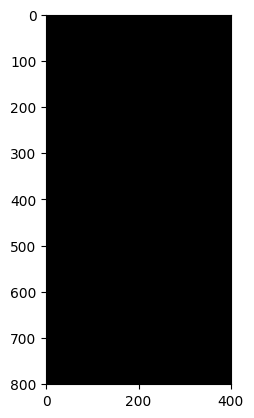

In [288]:
plt.imshow(tela)

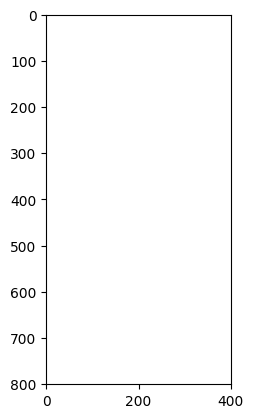

In [289]:
tela = tela + 255
plt.imshow(tela)

In [290]:
p11 = (0,0)
p21 = (l-1,0)
p_base = ((l-1) // 2, h-1)

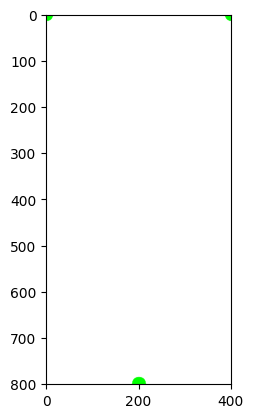

In [291]:
import cv2

cv2.circle(tela, p11, 15, (0,255,0), -1)
plt.imshow(tela)

cv2.circle(tela, p_base, 15, (0,255,0), -1)
plt.imshow(tela)

cv2.circle(tela, p21, 15, (0,255,0), -1)
plt.imshow(tela)

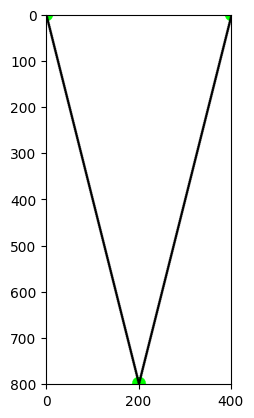

In [292]:
cv2.line(tela, p11, p_base, (0,0,0), 3)
cv2.line(tela, p21, p_base, (0,0,0), 3)
plt.imshow(tela)

In [293]:
a1 = 2 * (h-1) / (l-1)
b1 = 0

a2 = 2 * (h-1) / (1-l)
b2 = 2 * h

f1= lambda x: a1 * x + b1
f2= lambda x: a2 * x + b2



In [294]:
x_pontos_1 = np.linspace(start=0, stop=(l-1)//2, num=qtd_pontos+3).astype(int)
x_pontos_1 = x_pontos_1[1:-1]
display(x_pontos_1)

x_pontos_2 = np.linspace(start=(l-1)//2, stop=l-1, num=qtd_pontos+3).astype(int)
x_pontos_2 = x_pontos_2[1:-1]
display(x_pontos_2)

#===============================================================#

np.set_printoptions(legacy='1.13')
y_pontos_1 = np.array(list(map(f1, x_pontos_1))).round(0).astype(int)


np.set_printoptions(legacy='1.13')
y_pontos_2 = np.array(list(map(f2, x_pontos_2))).round(0).astype(int)
print(x_pontos_2)
print(y_pontos_2)



array([ 16,  33,  50,  66,  83, 100, 116, 133, 150, 166, 183])

array([216, 233, 250, 266, 283, 300, 316, 333, 350, 366, 383])

[216 233 250 266 283 300 316 333 350 366 383]
[738 670 602 538 470 402 338 270 202 138  70]


In [295]:
pontos_1 = list(zip(x_pontos_1, y_pontos_1))
display(pontos_1)
pontos_2 = list(zip(x_pontos_2, y_pontos_2))
display(pontos_2)




[(16, 64),
 (33, 132),
 (50, 200),
 (66, 264),
 (83, 332),
 (100, 400),
 (116, 464),
 (133, 532),
 (150, 600),
 (166, 664),
 (183, 732)]

[(216, 738),
 (233, 670),
 (250, 602),
 (266, 538),
 (283, 470),
 (300, 402),
 (316, 338),
 (333, 270),
 (350, 202),
 (366, 138),
 (383, 70)]

[{'a': 3.3700000000000001, 'b': 10.080000000000066},
 {'a': 2.6899999999999995, 'b': 43.230000000000111},
 {'a': 2.0100000000000002, 'b': 99.499999999999986},
 {'a': 1.3700000000000001, 'b': 173.58000000000015},
 {'a': 0.69000000000000028, 'b': 274.72999999999996},
 {'a': 0.010000000000000474, 'b': 398.99999999999989},
 {'a': -0.63000000000000023, 'b': 537.08000000000015},
 {'a': -1.3100000000000005, 'b': 706.2299999999999},
 {'a': -1.9899999999999998, 'b': 898.49999999999955},
 {'a': -2.629999999999999, 'b': 1100.5799999999997},
 {'a': -3.3100000000000005, 'b': 1337.73}]

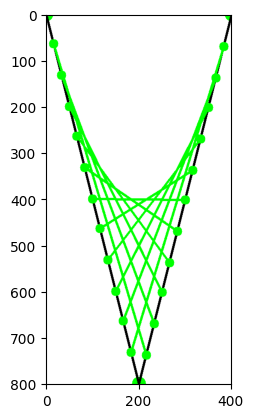

In [296]:
retas = []

for ponto_1, ponto_2 in zip(pontos_1, pontos_2):
    cv2.circle(tela, ponto_1, 10, (0,255,0), -1)
    cv2.circle(tela, ponto_2, 10, (0,255,0), -1)
    cv2.line(tela, ponto_1, ponto_2, (0,255,0), 3)
    plt.imshow(tela)

    a,b = np.polyfit(np.array([ponto_1[0], ponto_2[0]]), np.array([ponto_1[1], ponto_2[1]]), deg=1)
    
    reta = {"a": a, "b": b}
    retas.append(reta)

plt.imshow(tela)
display(retas)
    

In [297]:
from itertools import pairwise

retas_pareadas = list(pairwise(retas))
display(retas_pareadas)

[({'a': 3.3700000000000001, 'b': 10.080000000000066},
  {'a': 2.6899999999999995, 'b': 43.230000000000111}),
 ({'a': 2.6899999999999995, 'b': 43.230000000000111},
  {'a': 2.0100000000000002, 'b': 99.499999999999986}),
 ({'a': 2.0100000000000002, 'b': 99.499999999999986},
  {'a': 1.3700000000000001, 'b': 173.58000000000015}),
 ({'a': 1.3700000000000001, 'b': 173.58000000000015},
  {'a': 0.69000000000000028, 'b': 274.72999999999996}),
 ({'a': 0.69000000000000028, 'b': 274.72999999999996},
  {'a': 0.010000000000000474, 'b': 398.99999999999989}),
 ({'a': 0.010000000000000474, 'b': 398.99999999999989},
  {'a': -0.63000000000000023, 'b': 537.08000000000015}),
 ({'a': -0.63000000000000023, 'b': 537.08000000000015},
  {'a': -1.3100000000000005, 'b': 706.2299999999999}),
 ({'a': -1.3100000000000005, 'b': 706.2299999999999},
  {'a': -1.9899999999999998, 'b': 898.49999999999955}),
 ({'a': -1.9899999999999998, 'b': 898.49999999999955},
  {'a': -2.629999999999999, 'b': 1100.5799999999997}),
 ({'a':

49 174
83 266
116 332
149 377
183 401
216 401
249 380
283 336
316 270
349 183


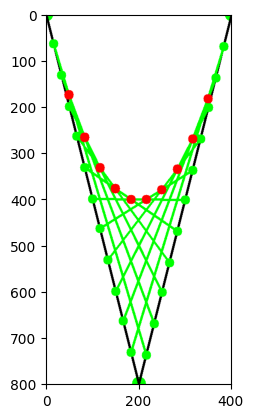

In [314]:
x_pontos_parabola = []
y_pontos_parabola = []

for reta_1, reta_2 in retas_pareadas:
    a1 = reta_1["a"]
    b1 = reta_1["b"]
    a2 = reta_2["a"]
    b2 = reta_2["b"]
    x_intersecao = (b2 - b1) / (a1 - a2)
    y_intersecao = a1 * x_intersecao + b1
    x_intersecao = int(round(x_intersecao, 0))
    y_intersecao = int(round(y_intersecao, 0))
    print(x_intersecao, y_intersecao)
    cv2.circle(tela, (x_intersecao, y_intersecao), 10, (255,0,0), -1)
    x_pontos_parabola.append(x_intersecao)
    y_pontos_parabola.append(y_intersecao)
plt.imshow(tela)    

In [315]:
print(x_pontos_parabola)
print(y_pontos_parabola)

[49, 83, 116, 149, 183, 216, 249, 283, 316, 349]
[174, 266, 332, 377, 401, 401, 380, 336, 270, 183]


In [1]:
coefs = np.polyfit(x_pontos_parabola, y_pontos_parabola, deg=2)

from sympy import *
x = symbols('x')
display(round(coefs[0], 3) * x**2 + round(coefs[1], 3) * x + round(coefs[2], 3))

NameError: name 'np' is not defined

In [2]:
print("champola")

champola
